In [ ]:
from pathlib import Path
import sys
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import seaborn as sns
from IPython.display import display, SVG
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import auc, precision_recall_curve, r2_score


DATA_DIR = Path("data")
ASSETS_DIR = Path("assets")
ALL_TABLES_DIR = DATA_DIR / "all_tables_processed"


PUBLICATION_FONT = "Nimbus Sans"
PUBLICATION_FONT_STACK = [
    PUBLICATION_FONT,
    "Arial",
    "Helvetica",
    "DejaVu Sans",
    "Liberation Sans",
    "sans-serif",
]


PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": PUBLICATION_FONT_STACK,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="whitegrid", font=PUBLICATION_FONT, rc=PLOT_STYLE)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

figure_exports = {}

rank_order = ["species", "genus", "family", "order", "class", "phylum", "domain"]


def read_all_tables(columns, filter_expr=None):
    dataset = ds.dataset(ALL_TABLES_DIR, format="parquet")
    return dataset.to_table(columns=columns, filter=filter_expr).to_pandas()


def numeric_columns(df, columns):
    df = df.copy()
    for col in columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

In [41]:
# Figure 1: load and prepare treemap and UpSet inputs
figure1_genomes = pd.read_csv(ASSETS_DIR / "genome_taxonomy.csv")
figure1_genomes = figure1_genomes.rename(columns={"genome": "GENOME_ID"})
for col in figure1_genomes.select_dtypes(include="object"):
    figure1_genomes[col] = figure1_genomes[col].str.strip()

figure1_tax_levels = ["domain", "phylum", "class", "order", "family", "genus", "species"]
figure1_treemap_threshold = 100
figure1_binned_genomes = figure1_genomes.copy()
for level in figure1_tax_levels:
    low_count = figure1_binned_genomes[level].value_counts()
    low_count = low_count[low_count <= figure1_treemap_threshold].index
    figure1_binned_genomes[level] = figure1_binned_genomes[level].replace(low_count, f"{level}_other")

figure1_genera = pd.read_csv(ASSETS_DIR / "genera_classification_sources_environmental.csv")
figure1_genera.columns = [col.strip().lower() for col in figure1_genera.columns]

figure1_base_cats = ["industry", "agriculture", "public_health"]
figure1_label_map = {
    "industry": "Industry",
    "agriculture": "Agriculture",
    "public_health": "Public Health",
    "other": "Other",
}


def figure1_to01(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return (numeric.fillna(0) > 0).astype(int)
    return series.astype(str).str.strip().str.lower().isin({"1", "true", "t", "yes", "y", "x"}).astype(int)


figure1_required_cols = ["genus", "count", *figure1_base_cats]
figure1_missing_cols = [col for col in figure1_required_cols if col not in figure1_genera.columns]
if figure1_missing_cols:
    raise ValueError(f"Missing expected Figure 1 columns: {figure1_missing_cols}")

figure1_genera = figure1_genera[figure1_required_cols].copy()
for col in figure1_base_cats:
    figure1_genera[col] = figure1_to01(figure1_genera[col])

figure1_genera["other"] = (figure1_genera[figure1_base_cats].sum(axis=1) == 0).astype(int)
figure1_cats = ["industry", "agriculture", "public_health", "other"]
figure1_genera["count"] = pd.to_numeric(figure1_genera["count"], errors="coerce").fillna(0)

figure1_genome_bin_labels = ["1", "1-10", "10-100", "100-1000", ">1000"]
figure1_genera["genome_bin"] = pd.cut(
    figure1_genera["count"],
    bins=[-1, 1, 10, 100, 1000, float("inf")],
    labels=figure1_genome_bin_labels,
)
figure1_genome_bin_counts = figure1_genera["genome_bin"].value_counts().reindex(figure1_genome_bin_labels, fill_value=0)
figure1_set_sizes = figure1_genera[figure1_cats].sum().loc[figure1_cats]

figure1_combo_values = []
for _, row in figure1_genera[figure1_cats].iterrows():
    figure1_combo_values.append(tuple(row.values))

figure1_combo_counts = pd.Series(figure1_combo_values).value_counts()
figure1_combo_counts = figure1_combo_counts[[any(combo) for combo in figure1_combo_counts.index]]
figure1_combo_counts = figure1_combo_counts.sort_values(ascending=False)
figure1_combos = list(figure1_combo_counts.index)
figure1_intersection_counts = figure1_combo_counts.values

print(
    f"Figure 1A: {len(figure1_genomes):,} genomes; "
    f"{figure1_binned_genomes['phylum'].nunique():,} phylum groups after binning"
)
print(f"Figure 1B: {len(figure1_genera):,} genera")


Figure 1A: 7,443 genomes; 5 phylum groups after binning
Figure 1B: 81 genera


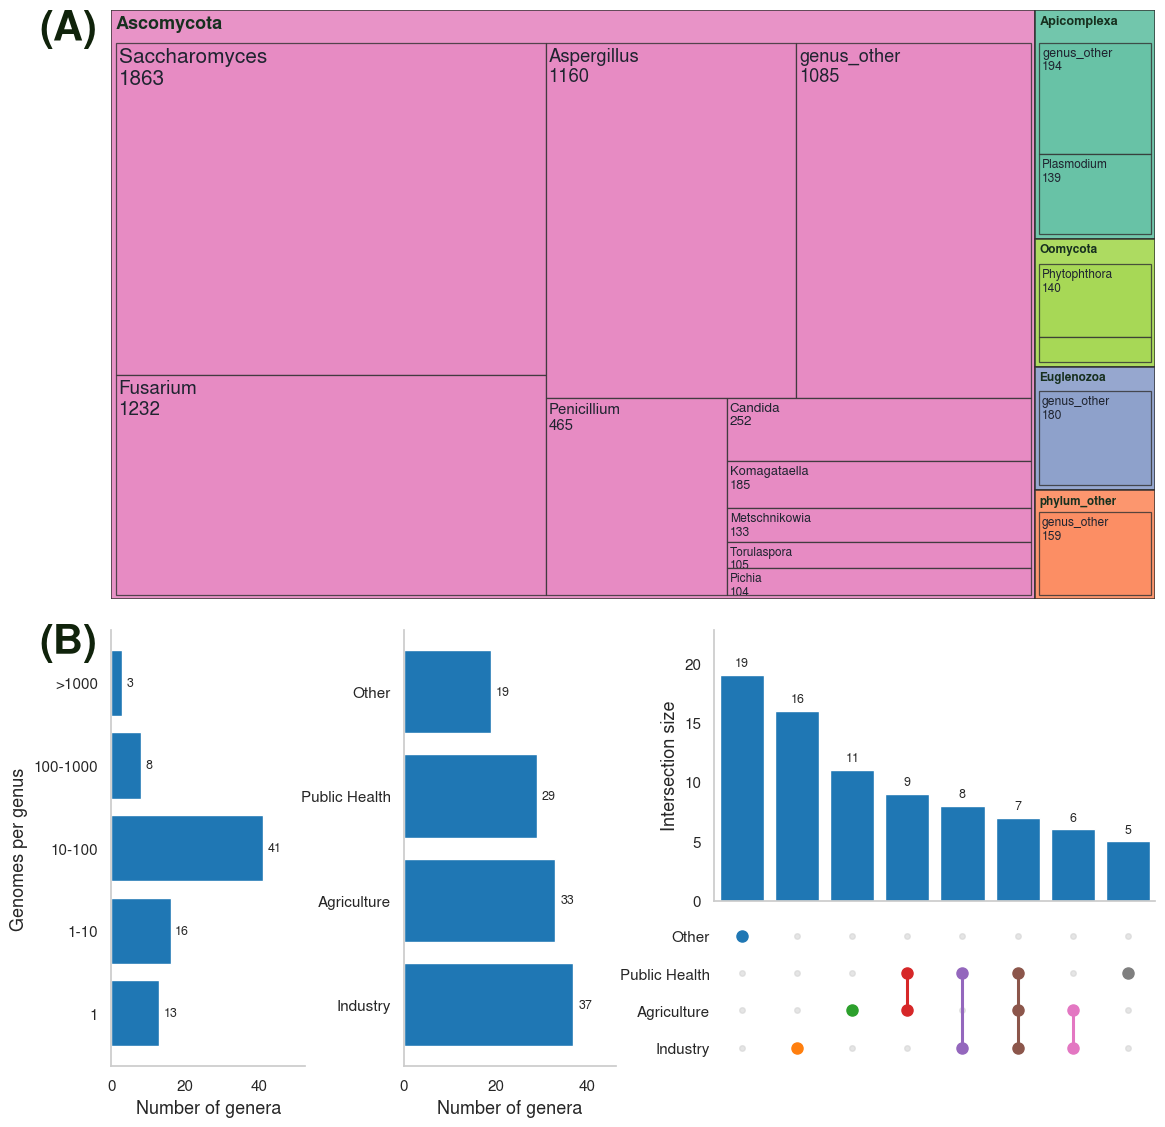

In [42]:
# Figure 1: final composite plot
from matplotlib.colors import to_rgb
from matplotlib.patches import Rectangle

FIG1_LABEL_SIZE = 13
FIG1_TICK_SIZE = 11
FIG1_SMALL_TEXT_SIZE = 9
FIG1_PANEL_LABEL_SIZE = 30
FIG1_BAR_COLOR = "#1f77b4"
FIG1_SET2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]


def figure1_squarify(items, x, y, dx, dy):
    items = [item.copy() for item in items if item["value"] > 0]
    total = sum(item["value"] for item in items)
    if not items or total <= 0 or dx <= 0 or dy <= 0:
        return []
    area = dx * dy
    for item in items:
        item["area"] = item["value"] * area / total

    def worst_ratio(row, side):
        if not row:
            return float("inf")
        row_area = sum(item["area"] for item in row)
        max_area = max(item["area"] for item in row)
        min_area = min(item["area"] for item in row)
        if min_area <= 0 or row_area <= 0 or side <= 0:
            return float("inf")
        return max((side**2 * max_area) / (row_area**2), (row_area**2) / (side**2 * min_area))

    def layout_row(row, x, y, dx, dy):
        rects = []
        row_area = sum(item["area"] for item in row)
        if dx >= dy:
            row_h = row_area / dx
            cursor = x
            for item in row:
                rect_w = item["area"] / row_h
                rects.append({**item, "x": cursor, "y": y, "dx": rect_w, "dy": row_h})
                cursor += rect_w
            return rects, x, y + row_h, dx, dy - row_h
        row_w = row_area / dy
        cursor = y
        for item in row:
            rect_h = item["area"] / row_w
            rects.append({**item, "x": x, "y": cursor, "dx": row_w, "dy": rect_h})
            cursor += rect_h
        return rects, x + row_w, y, dx - row_w, dy

    remaining = items[:]
    row = []
    rects = []
    while remaining:
        candidate = remaining[0]
        side = min(dx, dy)
        if not row or worst_ratio(row + [candidate], side) <= worst_ratio(row, side):
            row.append(candidate)
            remaining.pop(0)
        else:
            laid_out, x, y, dx, dy = layout_row(row, x, y, dx, dy)
            rects.extend(laid_out)
            row = []
    if row:
        laid_out, x, y, dx, dy = layout_row(row, x, y, dx, dy)
        rects.extend(laid_out)
    return rects


def figure1_luminance(color):
    r, g, b = to_rgb(color)
    return 0.299 * r + 0.587 * g + 0.114 * b


def figure1_draw_text(ax, patch, x, y, text, fontsize, color="#223", weight="normal"):
    txt = ax.text(x, y, text, fontsize=fontsize, color=color, va="top", ha="left", weight=weight, clip_on=True)
    txt.set_clip_path(patch)
    return txt


def figure1_top_level_rects(phylum_counts, width=1.0, height=1.0):
    counts = phylum_counts.sort_values(ascending=False)
    total = counts.sum()
    largest = counts.index[0]
    largest_width = counts.iloc[0] / total
    rects = [{"label": largest, "value": counts.iloc[0], "x": 0, "y": 0, "dx": width * largest_width, "dy": height}]
    remaining = counts.iloc[1:]
    y_cursor = 0
    x_right = width * largest_width
    dx_right = width - x_right
    remaining_total = remaining.sum()
    for label, value in remaining.items():
        rect_h = height * value / remaining_total
        rects.append({"label": label, "value": value, "x": x_right, "y": y_cursor, "dx": dx_right, "dy": rect_h})
        y_cursor += rect_h
    return rects


def figure1_split_vertical(items, x, y, dx, dy):
    total = sum(item["value"] for item in items)
    rects = []
    cursor = y
    for item in items:
        rect_h = dy * item["value"] / total
        rects.append({**item, "x": x, "y": cursor, "dx": dx, "dy": rect_h})
        cursor += rect_h
    return rects


def figure1_split_horizontal(items, x, y, dx, dy):
    total = sum(item["value"] for item in items)
    rects = []
    cursor = x
    for item in items:
        rect_w = dx * item["value"] / total
        rects.append({**item, "x": cursor, "y": y, "dx": rect_w, "dy": dy})
        cursor += rect_w
    return rects


def figure1_child_rects(phylum, genus_counts, x, y, dx, dy):
    counts = genus_counts.sort_values(ascending=False)
    items = [{"label": genus, "value": int(value)} for genus, value in counts.items()]
    values = {item["label"]: item["value"] for item in items}

    if phylum == "Ascomycota" and {"Saccharomyces", "Fusarium", "Aspergillus", "genus_other", "Penicillium"}.issubset(values):
        rects = []
        left_items = [
            {"label": "Saccharomyces", "value": values["Saccharomyces"]},
            {"label": "Fusarium", "value": values["Fusarium"]},
        ]
        left_value = sum(item["value"] for item in left_items)
        total_value = sum(values.values())
        left_dx = dx * left_value / total_value
        rects.extend(figure1_split_vertical(left_items, x, y, left_dx, dy))

        right_x = x + left_dx
        right_dx = dx - left_dx
        right_total = total_value - left_value
        top_items = [
            {"label": "Aspergillus", "value": values["Aspergillus"]},
            {"label": "genus_other", "value": values["genus_other"]},
        ]
        top_value = sum(item["value"] for item in top_items)
        top_dy = dy * top_value / right_total
        rects.extend(figure1_split_horizontal(top_items, right_x, y, right_dx, top_dy))

        bottom_y = y + top_dy
        bottom_dy = dy - top_dy
        bottom_labels = [item["label"] for item in items if item["label"] not in {"Saccharomyces", "Fusarium", "Aspergillus", "genus_other"}]
        bottom_total = sum(values[label] for label in bottom_labels)
        pen_dx = right_dx * values["Penicillium"] / bottom_total
        rects.append({"label": "Penicillium", "value": values["Penicillium"], "x": right_x, "y": bottom_y, "dx": pen_dx, "dy": bottom_dy})

        small_labels = [label for label in bottom_labels if label != "Penicillium"]
        small_items = [{"label": label, "value": values[label]} for label in small_labels]
        rects.extend(figure1_squarify(small_items, right_x + pen_dx, bottom_y, right_dx - pen_dx, bottom_dy))
        return rects

    if len(items) == 1:
        return [{**items[0], "x": x, "y": y, "dx": dx, "dy": dy}]
    if len(items) == 2:
        if phylum in {"Apicomplexa", "Oomycota"} or dx < dy:
            return figure1_split_vertical(items, x, y, dx, dy)
        return figure1_split_horizontal(items, x, y, dx, dy)
    return figure1_squarify(items, x, y, dx, dy)


def plot_figure1_treemap(ax, binned_genomes):
    unique_phyla = list(binned_genomes["phylum"].drop_duplicates())
    phylum_colors = {phy: FIG1_SET2[i % len(FIG1_SET2)] for i, phy in enumerate(unique_phyla)}
    phylum_counts = binned_genomes["phylum"].value_counts()
    treemap_width = 1.92
    treemap_height = 1.0
    treemap_area = treemap_width * treemap_height
    padding = 0.008

    ax.set_xlim(0, treemap_width)
    ax.set_ylim(treemap_height, 0)
    ax.axis("off")

    for phylum_rect in figure1_top_level_rects(phylum_counts, width=treemap_width, height=treemap_height):
        phylum = phylum_rect["label"]
        color = phylum_colors[phylum]
        parent_patch = Rectangle(
            (phylum_rect["x"], phylum_rect["y"]),
            phylum_rect["dx"],
            phylum_rect["dy"],
            facecolor=color,
            edgecolor="0.18",
            linewidth=1.1,
            alpha=0.92,
        )
        ax.add_patch(parent_patch)
        phylum_area_frac = (phylum_rect["dx"] * phylum_rect["dy"]) / treemap_area
        figure1_draw_text(
            ax,
            parent_patch,
            phylum_rect["x"] + padding,
            phylum_rect["y"] + padding,
            phylum,
            fontsize=max(8, min(13, 7 + 10 * np.sqrt(phylum_area_frac))),
            color="#17301f" if figure1_luminance(color) > 0.58 else "white",
            weight="bold",
        )

        header_h = min(0.055, phylum_rect["dy"] * 0.20)
        inner_x = phylum_rect["x"] + padding
        inner_y = phylum_rect["y"] + header_h
        inner_dx = max(phylum_rect["dx"] - 2 * padding, 0)
        inner_dy = max(phylum_rect["dy"] - header_h - padding, 0)
        genus_counts = binned_genomes.loc[binned_genomes["phylum"] == phylum, "genus"].value_counts().sort_values(ascending=False)

        for genus_rect in figure1_child_rects(phylum, genus_counts, inner_x, inner_y, inner_dx, inner_dy):
            child_patch = Rectangle(
                (genus_rect["x"], genus_rect["y"]),
                genus_rect["dx"],
                genus_rect["dy"],
                facecolor=color,
                edgecolor="0.20",
                linewidth=0.9,
                alpha=0.82,
            )
            ax.add_patch(child_patch)
            rect_area_frac = (genus_rect["dx"] * genus_rect["dy"]) / treemap_area
            if rect_area_frac >= 0.006:
                font_size = float(np.clip(6.5 + 18 * np.sqrt(rect_area_frac), 7, 15))
                label = str(genus_rect["label"])
                if len(label) > 14 and genus_rect["dx"] < 0.16:
                    label = label[:12] + "..."
                figure1_draw_text(
                    ax,
                    child_patch,
                    genus_rect["x"] + padding * 0.65,
                    genus_rect["y"] + padding * 0.85,
                    f"{label}\n{genus_rect['value']}",
                    fontsize=font_size,
                    color="#1f2430",
                )


def add_figure1_panel_label(fig, ax, label, x_offset=0.045, y_offset=0.004):
    bbox = ax.get_position()
    fig.text(
        bbox.x0 - x_offset,
        bbox.y1 + y_offset,
        label,
        fontsize=FIG1_PANEL_LABEL_SIZE,
        fontweight="bold",
        va="top",
        ha="left",
        color="#10230b",
    )


fig = plt.figure(figsize=(12, 12))
outer = fig.add_gridspec(2, 1, height_ratios=[1.35, 1.0], hspace=0.06)
ax_tree = fig.add_subplot(outer[0])
upset_grid = outer[1].subgridspec(
    2,
    3,
    height_ratios=[3.0, 1.65],
    width_ratios=[2.2, 2.4, 5.0],
    hspace=0.08,
    wspace=0.35,
)
ax_bins = fig.add_subplot(upset_grid[:, 0])
ax_sets = fig.add_subplot(upset_grid[:, 1])
ax_bars = fig.add_subplot(upset_grid[0, 2])
ax_matrix = fig.add_subplot(upset_grid[1, 2], sharex=ax_bars)

plot_figure1_treemap(ax_tree, figure1_binned_genomes)

ax_bins.barh(figure1_genome_bin_counts.index.astype(str), figure1_genome_bin_counts.values, color=FIG1_BAR_COLOR)
ax_bins.set_xlabel("Number of genera", fontsize=FIG1_LABEL_SIZE)
ax_bins.set_ylabel("Genomes per genus", fontsize=FIG1_LABEL_SIZE)
ax_bins.tick_params(labelsize=FIG1_TICK_SIZE)
ax_bins.set_xlim(0, max(figure1_genome_bin_counts.values) * 1.28)
for i, val in enumerate(figure1_genome_bin_counts.values):
    ax_bins.text(val + max(figure1_genome_bin_counts.values) * 0.03, i, int(val), va="center", fontsize=FIG1_SMALL_TEXT_SIZE)
ax_bins.grid(False)
ax_bins.spines[["top", "right"]].set_visible(False)

ax_sets.barh([figure1_label_map[col] for col in figure1_set_sizes.index], figure1_set_sizes.values, color=FIG1_BAR_COLOR)
ax_sets.set_xlabel("Number of genera", fontsize=FIG1_LABEL_SIZE)
ax_sets.tick_params(labelsize=FIG1_TICK_SIZE)
ax_sets.set_xlim(0, max(figure1_set_sizes.values) * 1.25)
for i, val in enumerate(figure1_set_sizes.values):
    ax_sets.text(val + max(figure1_set_sizes.values) * 0.03, i, int(val), va="center", fontsize=FIG1_SMALL_TEXT_SIZE)
ax_sets.grid(False)
ax_sets.spines[["top", "right"]].set_visible(False)

x = np.arange(len(figure1_combos))
ax_bars.bar(x, figure1_intersection_counts, color=FIG1_BAR_COLOR)
ax_bars.set_ylabel("Intersection size", fontsize=FIG1_LABEL_SIZE)
ax_bars.set_xticks([])
ax_bars.tick_params(labelsize=FIG1_TICK_SIZE)
ax_bars.set_xlim(-0.5, len(figure1_combos) - 0.5)
ax_bars.set_ylim(0, max(figure1_intersection_counts) * 1.20)
for i, val in enumerate(figure1_intersection_counts):
    ax_bars.text(i, val + max(figure1_intersection_counts) * 0.025, int(val), ha="center", va="bottom", fontsize=FIG1_SMALL_TEXT_SIZE)
ax_bars.grid(False)
ax_bars.spines[["top", "right"]].set_visible(False)

ax_matrix.set_xlim(-0.5, len(figure1_combos) - 0.5)
ax_matrix.set_ylim(-0.5, len(figure1_cats) - 0.5)
ax_matrix.set_yticks(range(len(figure1_cats)))
ax_matrix.set_yticklabels([figure1_label_map[col] for col in figure1_cats], fontsize=FIG1_TICK_SIZE)
ax_matrix.set_xticks(range(len(figure1_combos)))
ax_matrix.set_xticklabels([""] * len(figure1_combos))
combo_colors = plt.cm.tab10(np.arange(len(figure1_combos)) % 10)
for j, combo in enumerate(figure1_combos):
    ys_on = [i for i, val in enumerate(combo) if val == 1]
    color = combo_colors[j]
    for i in range(len(figure1_cats)):
        ax_matrix.plot(
            j,
            i,
            "o",
            color=color if i in ys_on else "0.82",
            markersize=8 if i in ys_on else 4,
            alpha=1.0 if i in ys_on else 0.55,
        )
    if len(ys_on) >= 2:
        ax_matrix.plot([j, j], [min(ys_on), max(ys_on)], "-", color=color, linewidth=2.2)
ax_matrix.grid(False)
ax_matrix.spines[:].set_visible(False)
ax_matrix.tick_params(axis="x", length=0)
ax_matrix.tick_params(axis="y", length=0, labelsize=FIG1_TICK_SIZE)

fig.subplots_adjust(left=0.105, right=0.975, top=0.955, bottom=0.075)
add_figure1_panel_label(fig, ax_tree, "(A)", x_offset=0.060, y_offset=0.001)
add_figure1_panel_label(fig, ax_bins, "(B)", x_offset=0.060, y_offset=0.006)
figure1_fig = fig
figure_exports["figure1"] = figure1_fig
plt.show()
